In [1]:
%load_ext autoreload
%autoreload 2

In [6]:
import json


with open("/Users/pgul/GIGA_TOKEN.json") as f:
    token = json.load(f)["response"]
token

'eyJhbGciOiJkaXIiLCJlbmMiOiJBMTI4R0NNIiwidHlwIjoiSldUIn0..46o6FqUFcfP-IyLt.FodLNg9iGcJhjoKz5B5mkid545h5p_d5U7d4L0ZKtYmQLjFAbKBDphKdZ2lDSKkudRFIvxZ45diLn2U.ylx2U2d2Te-v-AiaqbtW8Q'

In [ ]:
import openai

client = openai.OpenAI(base_url="http://localhost:8001", api_key="sk-1234")

response = client.chat.completions.create(
    model="Minimax-M2.5", messages=[{"role": "user", "content": "Привет!"}]
)

print(response.choices[0].message.content)



Привет! Как дела? Чем я могу вам помочь?


### Check GC via requests

In [7]:
from pprint import pprint
import uuid
import requests
from gigachat import GigaChat


def giga_requests_response(model, content, functions=None, reasoning: bool = False):
    # reasoning = True if "Reasoning" in model else reasoning
    base_url = "https://gigachat.ift.sberdevices.ru/v1"
    headers = {
        "Content-Type": "application/json",
        "Accept": "application/json",
        "Authorization": f"Bearer {token}",
    }

    if functions is None:
        functions = []

    reasoning_effort = "medium" if reasoning else None

    payload = json.dumps(
        {
            "model": model,
            "messages": [
                # {"role": "system", "content": ""},
                # {"role": "assistant", "content": ""},
                {"role": "user", "content": content},
            ],
            "repetition_penalty": 1,
            "stream": False,
            "temperature": 0.001,
            "profanity_check": False,
            "reasoning_effort": reasoning_effort,
            "functions": functions,
            "function_call": "auto",
            "preset_name": "ag",
        }
    )

    response = requests.request(
        "POST",
        base_url + "/chat/completions",
        headers=headers,
        verify=False,
        data=payload,
    )
    return response


def giga_lib_response(model, content, functions=None, reasoning: bool = False):
    base_url = "https://gigachat.ift.sberdevices.ru/v1"
    if functions is None:
        functions = []

    reasoning_effort = "medium" if reasoning else None
    payload = {
        "messages": [{"role": "user", "content": content}],
        "repetition_penalty": 1,
        "stream": False,
        "temperature": 0.001,
        "reasoning_effort": reasoning_effort,
        "profanity_check": False,
        "functions": functions,
        "function_call": "auto",
    }

    giga = GigaChat(
        access_token=token,
        base_url=base_url,
        model=model,
        profanity_check=False,
        verify_ssl_certs=False,
        scope="GIGACHAT_API_CORP",
    )
    print(giga._settings.model)
    # pprint(giga.get_models().data)
    response = giga.chat(payload)
    return response

In [8]:
model = "GigaChat-3-Ultra"
# model = "GigaChat-2"
content = "Factorial 5"


factorial_function = {
    "name": "math.factorial",
    "description": "Calculate the factorial of a given positive integer.",
    "parameters": {
        "type": "dict",
        "properties": {
            "number": {
                "type": "number",
                "description": "The number for which factorial needs to be calculated.",
            }
        },
        "required": ["number"],
    },
}

response_requests = giga_requests_response(
    model, content, [factorial_function], reasoning=True
)
response_requests = giga_requests_response(
    model, content, functions=None, reasoning=False
)
request_id = response_requests.headers.get("x-request-id")
pprint(response_requests.json())
print(f"Request ID: {request_id}")
print("--" * 30)
response_lib = giga_lib_response(model, content, [factorial_function], reasoning=True)
pprint(response_lib)
# response_lib = giga_lib_response(model, content, None, reasoning=True)


/opt/miniconda3/envs/bfcl-v3/lib/python3.10/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'gigachat.ift.sberdevices.ru'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/opt/miniconda3/envs/bfcl-v3/lib/python3.10/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'gigachat.ift.sberdevices.ru'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


{'choices': [{'finish_reason': 'stop',
              'index': 0,
              'message': {'content': 'Факториал числа 5 (обозначается как '
                                     '$5!$) — это произведение всех целых '
                                     'чисел от 1 до 5:\n'
                                     '\n'
                                     '$$5! = 5 \\times 4 \\times 3 \\times 2 '
                                     '\\times 1 = 120.$$\n'
                                     '\n'
                                     '**Ответ:** $5! = 120$.',
                          'functions_state_id': '019c93ca-8475-7cf6-afd4-72016cf5fa17',
                          'role': 'assistant'}}],
 'created': 1772006048,
 'model': 'GigaChat-3-Ultra:32.3.19.2',
 'object': 'chat.completions',
 'usage': {'completion_tokens': 73,
           'precached_prompt_tokens': 0,
           'prompt_tokens': 722,
           'total_tokens': 795}}
Request ID: e112aa2f-0186-4754-88c3-2234434b2239
--------------

In [53]:
response_lib.choices[0].message.reasoning_content

In [ ]:
base_url = "https://gigachat.ift.sberdevices.ru/v1"
headers = {
    "Content-Type": "application/json",
    "Accept": "application/json",
    "Authorization": f"Bearer {token}",
}

content = "Изображение футболки со следующим дизайном: верх футболки (рукава и грудь) - небесного синего цвета, а вот остальная часть - жёлтого цвета, как лимон. На груди написано имя 'Слава'."
content = "Изображение нашего лидера"
payload = json.dumps(
    {
        "model": "GigaChat-2-Max",
        "stream": False,
        "update_interval": 0,
        "profanity_check": False,
        "top_p": 0.0,
        "repetition_penalty": 1,
        "max_tokens": 8192,
        "debug": False,
        "preset_name": "web",
        "function_call": "auto",
        "functions": [
            {"name": "get_datetime"},
            {"name": "actual_info_web_search"},
            {"name": "text2image"},
            {"name": "get_url_content"},
        ],
        "messages": [{"role": "user", "content": content}],
    }
)

response = requests.request(
    "POST", base_url + "/chat/completions", headers=headers, verify=False, data=payload
)
pprint(response.json())

/home/jovyan/.mlspace/envs/BFCL_new/lib/python3.10/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'gigachat.ift.sberdevices.ru'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


{'choices': [{'finish_reason': 'stop',
              'index': 0,
              'message': {'content': '<img '
                                     'src="adcf1528-0d2a-4539-ad19-e34fb695c3f0" '
                                     'fuse="true"/> Вот изображение нашего '
                                     'лидера.',
                          'functions_state_id': '019a3156-737e-70c0-886e-ab36e4cf6d42',
                          'role': 'assistant'}}],
 'created': 1761764340,
 'model': 'GigaChat-2-Max:2.0.30.01',
 'object': 'chat.completion',
 'usage': {'completion_tokens': 50,
           'precached_prompt_tokens': 5504,
           'prompt_tokens': 2351,
           'total_tokens': 2401}}


/home/jovyan/.mlspace/envs/BFCL_new/lib/python3.10/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'gigachat.ift.sberdevices.ru'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


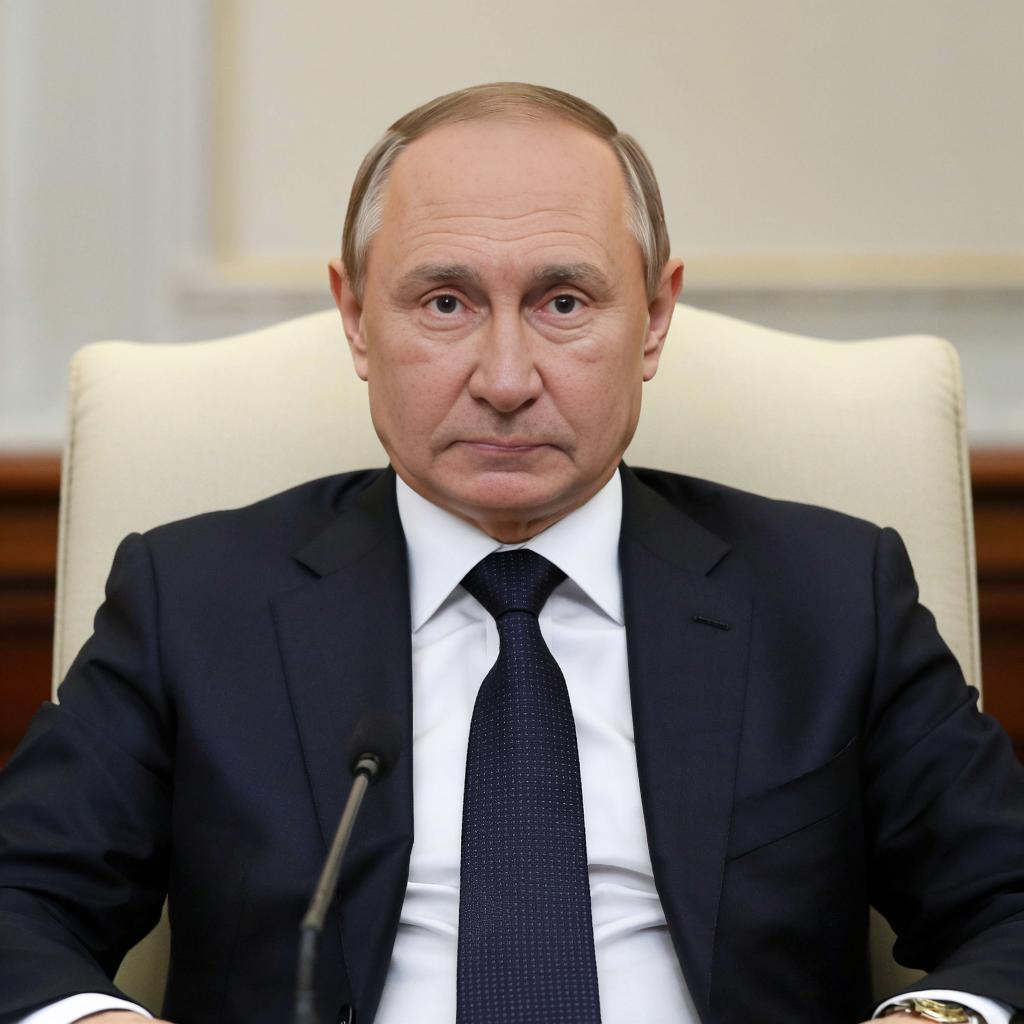

In [ ]:
from PIL import Image
from io import BytesIO

base_url = "https://gigachat.ift.sberdevices.ru/v1"
headers = {
    "Accept": "application/jpg",
    "Authorization": f"Bearer {token}",
}

image_id = "adcf1528-0d2a-4539-ad19-e34fb695c3f0"
get_image = requests.request(
    "GET", base_url + f"/files/{image_id}/content", verify=False, headers=headers
)

byte_stream = BytesIO(get_image.content)
image = Image.open(byte_stream)
image.show()

In [ ]:
model = "GigaChat-Max"
hcf_function = {
    "name": "math.hcf",
    "description": "Calculate the highest common factor of two numbers.",
    "parameters": {
        "type": "object",
        "properties": {
            "number1": {"type": "integer", "description": "First number."},
            "number2": {"type": "integer", "description": "Second number."},
        },
        "required": ["number1", "number2"],
    },
}
factorial_function = {
    "name": "math.factorial",
    "description": "Calculate the factorial of a given positive integer.",
    "parameters": {
        "type": "dict",
        "properties": {
            "number": {
                "type": "number",
                "description": "The number for which factorial needs to be calculated.",
            }
        },
        "required": ["number"],
    },
}

math_tutor_prompt = """
    You are a helpful math tutor. You will be provided with a math problem,
    and your goal will be to output a step by step solution, along with a final answer.
    For each step, just provide the output as an equation use the explanation field to detail the reasoning.
"""
math_reasoning = {
    "name": "math_reasoning",
    "description": "Math reasoning for a given user's query.",
    "parameters": {
        "type": "object",
        "properties": {
            "steps": {
                "type": "array",
                "items": {
                    "type": "object",
                    "properties": {
                        "explanation": {"type": "string"},
                        "output": {"type": "string"},
                    },
                    "required": ["explanation", "output"],
                    "additionalProperties": False,
                },
            },
            "final_answer": {"type": "string"},
        },
        "required": ["steps", "final_answer"],
        "additionalProperties": False,
    },
    "strict": True,
}

payload = json.dumps(
    {
        "model": model,
        "messages": [
            {"role": "system", "content": math_tutor_prompt},
            {
                "role": "user",
                # "content": "Find the highest common factor of 36 and 24 and then calculate factorial for 3.",
                "content": "how can I solve 8x + 7 = -23",
            },
        ],
        "stream": False,
        "repetition_penalty": 1,
        "temperature": 0.001,
        "function_call": "auto",
        # "functions": [hcf_function, factorial_function],
        "functions": [math_reasoning],
    }
)

response = requests.request(
    "POST", base_url + "/chat/completions", headers=headers, verify=False, data=payload
)
response.json()

NameError: name 'headers' is not defined

### Check GC via gigachat lib (do not apply json.dumps() on a JSON)

In [ ]:
# Prod creds
credentials = "ZTZkM2ZmODYtNDRmNC00OWQ0LTkyNTUtOTA1NzE1ZGY2ZTFjOmZkM2M5Nzk1LTY4ZjItNDU1Ni1hN2NlLWU5ODIzNzIwZDMwNg=="
base_url = "https://gigachat.devices.sberbank.ru/api/v1"

model = "GigaChat-2"
giga_prod = GigaChat(
    credentials=credentials,
    base_url=base_url,
    model=model,
    profanity_check=True,
    verify_ssl_certs=False,
    scope="GIGACHAT_API_CORP",
    timeout=200,
)

giga_prod.chat("omg")

ChatCompletion(x_headers={'x-request-id': 'e60ea66e-fae1-4146-b5cc-0a9065bf435d', 'x-session-id': 'ade9bcdb-0bc4-464f-bac5-5cae85fe03e0', 'x-client-id': None}, choices=[Choices(message=Messages(role='assistant', content='Ого! Что случилось?', function_call=None, name=None, attachments=None, data_for_context=None, functions_state_id=None, reasoning_content=None, id_=None), index=0, finish_reason='stop')], created=1768814467, model='GigaChat-2:2.0.28.2', thread_id=None, message_id=None, usage=Usage(prompt_tokens=11, completion_tokens=7, total_tokens=18, precached_prompt_tokens=2), object_='chat.completion')

In [124]:
# IFT
base_url = "https://gigachat.ift.sberdevices.ru/v1"
model = "GigaChat-2"

payload = {
    "messages": [{"role": "user", "content": "OMG"}],
    "repetition_penalty": 1,
    "stream": False,
    "temperture": 0.001,
}


giga = GigaChat(
    access_token=token,
    base_url=base_url,
    model=model,
    profanity_check=True,
    verify_ssl_certs=False,
    scope="GIGACHAT_API_CORP",
    timeout=200,
)

# print(giga.get_models())

response = giga.chat(payload)
print(response)

x_headers={'x-request-id': '190d732f-4ce0-417b-94c3-0b07d14e9e21', 'x-session-id': '2eb8e312-06b2-4154-98ef-717f8b8b173a', 'x-client-id': None} choices=[Choices(message=Messages(role='assistant', content='Что-то стряслось?', function_call=None, name=None, attachments=None, data_for_context=None, functions_state_id=None, reasoning_content=None, id_=None), index=0, finish_reason='stop')] created=1769756751 model='GigaChat-2:2.0.30.01' thread_id=None message_id=None usage=Usage(prompt_tokens=21, completion_tokens=9, total_tokens=30, precached_prompt_tokens=0) object_='chat.completions'


In [125]:
giga.get_models().data

[Model(x_headers=None, id_='GigaChat', object_='model', owned_by='salutedevices'),
 Model(x_headers=None, id_='GigaChat-2', object_='model', owned_by='salutedevices'),
 Model(x_headers=None, id_='GigaChat-2-Max', object_='model', owned_by='salutedevices'),
 Model(x_headers=None, id_='GigaChat-2-Pro', object_='model', owned_by='salutedevices'),
 Model(x_headers=None, id_='GigaChat-3-Ultra', object_='model', owned_by='salutedevices'),
 Model(x_headers=None, id_='GigaChat-Max', object_='model', owned_by='salutedevices'),
 Model(x_headers=None, id_='GigaChat-Pro', object_='model', owned_by='salutedevices'),
 Model(x_headers=None, id_='Embeddings', object_='model', owned_by='salutedevices'),
 Model(x_headers=None, id_='Embeddings-2', object_='model', owned_by='salutedevices'),
 Model(x_headers=None, id_='EmbeddingsGigaR', object_='model', owned_by='salutedevices'),
 Model(x_headers=None, id_='GigaEmbeddings-3B-2025-09', object_='model', owned_by='salutedevices')]

In [ ]:
# PROD
credentials = "ZTZkM2ZmODYtNDRmNC00OWQ0LTkyNTUtOTA1NzE1ZGY2ZTFjOmZkM2M5Nzk1LTY4ZjItNDU1Ni1hN2NlLWU5ODIzNzIwZDMwNg=="
base_url = "https://gigachat.devices.sberbank.ru/api/v1"
payload = {
    "messages": [
        {"role": "user", "content": "Расскажи самый уморительный анекдот на свете"}
    ],
    "repetition_penalty": 1,
    "stream": False,
}


giga = GigaChat(
    credentials=credentials,
    # base_url=base_url,
    model=model,
    profanity_check=False,
    verify_ssl_certs=False,
    scope="GIGACHAT_API_CORP",
)
response = giga.chat(payload)
# print(response.choices[0].message.content)
print(response)


choices=[Choices(message=Messages(role='assistant', content='Вот один из самых популярных анекдотов:\n\n— Доктор, у меня мания величия!\n— Это с чего вы взяли?\n— Ну, я же самый умный!', function_call=None, name=None, attachments=None, data_for_context=None, functions_state_id=None, id_=None), index=0, finish_reason='stop')] created=1741867700 model='GigaChat-Max:1.0.26.20' usage=Usage(prompt_tokens=25, completion_tokens=39, total_tokens=64) object_='chat.completion'


In [6]:
giga.get_models()

Models(data=[Model(id_='GigaChat', object_='model', owned_by='salutedevices'), Model(id_='GigaChat-2', object_='model', owned_by='salutedevices'), Model(id_='GigaChat-2-Max', object_='model', owned_by='salutedevices'), Model(id_='GigaChat-2-Pro', object_='model', owned_by='salutedevices'), Model(id_='GigaChat-2-Reasoning', object_='model', owned_by='salutedevices'), Model(id_='GigaChat-Max', object_='model', owned_by='salutedevices'), Model(id_='GigaChat-Pro', object_='model', owned_by='salutedevices'), Model(id_='Embeddings', object_='model', owned_by='salutedevices'), Model(id_='Embeddings-2', object_='model', owned_by='salutedevices'), Model(id_='EmbeddingsGigaR', object_='model', owned_by='salutedevices'), Model(id_='GigaInstruct', object_='model', owned_by='salutedevices')], object_='list')

In [ ]:
def load_file(file_path: str):
    result = []
    with open(file_path) as f:
        file = f.readlines()
        for line in file:
            result.append(json.loads(line))
    return result

### Testing BFCL pipeline

In [ ]:
from pathlib import Path
from typing import Optional, List

import pandas as pd
import plotly.express as px


def load_results_df(json_path: Path) -> pd.DataFrame:
    """
    Load a result JSON file into a DataFrame using pandas.

    Tries JSON Lines first (common for logs), then normal JSON.
    """
    try:
        # JSON Lines format: one JSON object per line
        return pd.read_json(json_path, lines=True)
    except ValueError:
        # Fallback: standard JSON (array or object)
        return pd.read_json(json_path)


def extract_error_code(error_msg: str) -> Optional[str]:
    """
    Extract error code from the error message.

    Assumes the message can be split by ',' and the second
    element is the error code, e.g.:

        "Error during inference, 500, something something"

    Returns the error code as a string (e.g. "500"), or None
    if it cannot be extracted.
    """
    if not isinstance(error_msg, str):
        return None

    parts = error_msg.split(",")
    if len(parts) < 2:
        return None

    code = parts[1].strip()
    # Optionally keep only numeric codes
    if not code.isdigit():
        return None

    return code


def gather_error_stats(
    results_dir: str,
    file_pattern: str = "*.json",
    error_prefix: str = "Error during inference",
) -> pd.DataFrame:
    """
    Iterate over result JSON files, gather error codes into a single DataFrame
    (with columns: category, error_code), and draw per-category and overall
    error bar plots using Plotly.

    Parameters
    ----------
    results_dir : str
        Directory containing JSON result files.
    file_pattern : str, optional
        Glob pattern for result files, by default "*_result.json".
    error_prefix : str, optional
        String indicating an error in the 'result' field, by default
        "Error during inference".

    Returns
    -------
    pd.DataFrame
        DataFrame of all error rows with at least:
        - 'category'
        - 'error_code'
        - 'result'
    """
    base_path = Path(results_dir)
    all_error_dfs: List[pd.DataFrame] = []

    for json_path in sorted(base_path.rglob(file_pattern)):
        df = load_results_df(json_path)

        if "result" not in df.columns:
            print(f"Skipping {json_path.name}: no 'result' column found.")
            continue

        # Derive category from filename, e.g. BFCL_v3_irrelevance_result.json -> BFCL_v3_irrelevance
        category = json_path.stem.replace("_result", "")

        # Filter rows where result starts with the error prefix
        result_str = df["result"].astype(str)
        error_mask = result_str.str.startswith(error_prefix)

        df_errors = df.loc[error_mask].copy()
        if df_errors.empty:
            continue

        df_errors["category"] = category
        df_errors["error_code"] = result_str[error_mask].apply(extract_error_code)

        # Drop rows where we couldn't parse an error code
        df_errors = df_errors[df_errors["error_code"].notna()]

        if not df_errors.empty:
            all_error_dfs.append(df_errors)

    if not all_error_dfs:
        print("No errors found with the given prefix / pattern.")
        return pd.DataFrame(columns=["category", "error_code", "result"])

    errors_df = pd.concat(all_error_dfs, ignore_index=True)

    # ---- Plot per-category stats ----
    # for category, cat_df in errors_df.groupby("category"):
    #     counts = (
    #         cat_df["error_code"]
    #         .value_counts()
    #         .rename_axis("error_code")
    #         .reset_index(name="count")
    #     )

    #     fig = px.bar(
    #         counts,
    #         x="error_code",
    #         y="count",
    #         title=f"Error codes for '{category}'",
    #         labels={"error_code": "Error code", "count": "Count"},
    #     )
    #     # Show if running interactively (e.g. notebook) – safe to keep
    #     fig.show()

    #     # Also save as HTML for later inspection
    #     out_html = base_path / f"{category}_error_stats.html"
    #     fig.write_html(out_html)
    #     print(f"[per-category] Saved interactive plot: {out_html}")

    # ---- Plot overall stats ----
    overall_counts = (
        errors_df["error_code"]
        .value_counts()
        .rename_axis("error_code")
        .reset_index(name="count")
    )

    fig_overall = px.bar(
        overall_counts,
        x="error_code",
        y="count",
        text="count",
        title="Error codes across all categories",
        labels={"error_code": "Error code", "count": "Count"},
    )
    fig_overall.update_traces(textposition="outside")
    fig_overall.show()

    overall_html = base_path / "all_categories_error_stats.html"
    fig_overall.write_html(overall_html)
    print(f"[overall] Saved interactive plot: {overall_html}")

    # ---- Grouped bars: all categories in one figure ----
    grouped = (
        errors_df.groupby(["error_code", "category"]).size().reset_index(name="count")
    )

    fig_grouped = px.bar(
        grouped,
        x="error_code",
        y="count",
        color="category",  # different color per category
        barmode="group",  # grouped bars per error code
        text="count",  # show counts on bars
        title="Error codes per category",
        labels={"error_code": "Error code", "count": "Count", "category": "Category"},
    )

    # Put numbers above bars
    fig_grouped.update_traces(textposition="outside")

    # Make it a bit nicer / readable
    fig_grouped.update_layout(
        xaxis_type="category",
        legend_title_text="Category",
        margin=dict(t=60, b=60),
    )

    fig_grouped.show()

    out_html = base_path / "error_codes_grouped_by_category.html"
    fig_grouped.write_html(out_html)
    print(f"[grouped] Saved interactive grouped-bar plot: {out_html}")
    return errors_df

In [ ]:
result_dir = "./GC_2_2905_Reasoning/gc"
errors_df = gather_error_stats(result_dir)

In [ ]:
import pandas as pd
from pathlib import Path


def check_errors(result_json: Path):
    result_df = pd.read_json(result_json, lines=True)
    errors = result_df[
        result_df["result"].str.contains(r"Error during inference", na=False)
    ]
    print(result_json.stem)
    print("Number of errors:")
    print(errors.shape[0])
    print("Errors:")
    for i, content in errors.result.items():
        print(i, content)
    print("==" * 30)
    return errors


def get_errors_stats(result_dir: str | Path):
    pass

## Qwen

In [ ]:
single_turn = [
    "simple",
    "multiple",
    # "parallel",
    # "parallel_multiple",
    "live_simple",
    "live_multiple",
    # "live_parallel",
    # "live_parallel_multiple",
    "java",
    "javascript",
    "irrelevance",
    "live_irrelevance",
    "live_relevance",
]


all_categorites = single_turn + ["multi_turn"]


# result_dir = "GC_2_0_3001/gc"
result_dir = "qwen3-next-80b"
# test_categories = ["multi_turn"]

generate(
    model=["qwen3-next-80b-a3b-instruct"],
    # test_category=["multi_turn_miss_func", "multi_turn_miss_param"],
    # test_category=single_turn,
    test_category=["multi_turn"],
    # test_category=["simple"],
    temperature=0.001,
    num_threads=3,
    result_dir=result_dir,
    include_input_log=False,
    exclude_state_log=False,
    num_gpus=1,
    gpu_memory_utilization=0.9,
    run_ids=False,
)

In [ ]:
import pandas as pd
from pathlib import Path


def check_errors(result_json: Path):
    result_df = pd.read_json(result_json, lines=True)
    errors = result_df[
        result_df["result"].str.contains(r"Error during inference", na=False)
    ]
    print(result_json.stem)
    print("Number of errors:")
    print(errors.shape[0])
    print("Errors:")
    for i, content in errors.result.items():
        print(i, content)
    print("==" * 30)

In [6]:
result_dir = "qwen3-next-80b"

for f in Path(result_dir, "qwen_qwen3-next-80b-a3b-instruct").rglob("*.json"):
    check_errors(f.absolute())

BFCL_v3_irrelevance_result
Number of errors:
0
Errors:
BFCL_v3_java_result
Number of errors:
0
Errors:
BFCL_v3_javascript_result
Number of errors:
0
Errors:
BFCL_v3_live_irrelevance_result
Number of errors:
0
Errors:
BFCL_v3_live_multiple_result
Number of errors:
0
Errors:
BFCL_v3_live_relevance_result
Number of errors:
0
Errors:
BFCL_v3_live_simple_result
Number of errors:
0
Errors:
BFCL_v3_multiple_result
Number of errors:
0
Errors:
BFCL_v3_simple_result
Number of errors:
0
Errors:
BFCL_v3_multi_turn_base_result
Number of errors:
0
Errors:
BFCL_v3_multi_turn_long_context_result
Number of errors:
0
Errors:
BFCL_v3_multi_turn_miss_func_result
Number of errors:
0
Errors:
BFCL_v3_multi_turn_miss_param_result
Number of errors:
0
Errors:


In [13]:
from bfcl.eval_checker.eval_runner import main

In [ ]:
result_dir = "gpt5"
score_dir = f"{result_dir}_SCORE"
main(
    model=["gpt5"],
    test_categories=["all"],
    api_sanity_check=False,
    result_dir=result_dir,
    score_dir=score_dir,
)

{'BFCL_v3_live_parallel.json', 'BFCL_v3_rest.json', 'BFCL_v3_multi_turn_base.json', 'BFCL_v3_exec_parallel.json', 'BFCL_v3_java.json', 'BFCL_v3_multi_turn_miss_param.json', 'BFCL_v3_irrelevance.json', 'BFCL_v3_live_parallel_multiple.json', 'BFCL_v3_multi_turn_long_context.json', 'BFCL_v3_exec_parallel_multiple.json', 'BFCL_v3_live_irrelevance.json', 'BFCL_v3_live_simple.json', 'BFCL_v3_multiple.json', 'BFCL_v3_exec_multiple.json', 'BFCL_v3_javascript.json', 'BFCL_v3_exec_simple.json', 'BFCL_v3_multi_turn_miss_func.json', 'BFCL_v3_simple.json', 'BFCL_v3_parallel_multiple.json', 'BFCL_v3_live_multiple.json', 'BFCL_v3_parallel.json', 'BFCL_v3_live_relevance.json'}


Number of models evaluated: 100%|██████████| 1/1 [00:00<00:00, 2101.35it/s]

🦍 Model: gpt5
📈 Aggregating data to generate leaderboard score table...
🏁 Evaluation completed. See /home/jovyan/gigachat/function_calling/gorilla/berkeley-function-call-leaderboard/gpt5_SCORE/data_overall.csv for overall evaluation results on BFCL V3.
See /home/jovyan/gigachat/function_calling/gorilla/berkeley-function-call-leaderboard/gpt5_SCORE/data_live.csv, /home/jovyan/gigachat/function_calling/gorilla/berkeley-function-call-leaderboard/gpt5_SCORE/data_non_live.csv and /home/jovyan/gigachat/function_calling/gorilla/berkeley-function-call-leaderboard/gpt5_SCORE/data_multi_turn.csv for detailed evaluation results on each sub-section categories respectively.


In [8]:
result_dir = "qwen3-next-80b"

In [ ]:
score_dir = f"{result_dir}_SCORE"
main(
    model=["qwen3-next-80b-a3b-instruct"],
    test_categories=["all"],
    api_sanity_check=False,
    result_dir=result_dir,
    score_dir=score_dir,
)

{'BFCL_v3_live_parallel.json', 'BFCL_v3_rest.json', 'BFCL_v3_multi_turn_base.json', 'BFCL_v3_exec_parallel.json', 'BFCL_v3_java.json', 'BFCL_v3_multi_turn_miss_param.json', 'BFCL_v3_irrelevance.json', 'BFCL_v3_live_parallel_multiple.json', 'BFCL_v3_multi_turn_long_context.json', 'BFCL_v3_exec_parallel_multiple.json', 'BFCL_v3_live_irrelevance.json', 'BFCL_v3_live_simple.json', 'BFCL_v3_multiple.json', 'BFCL_v3_exec_multiple.json', 'BFCL_v3_javascript.json', 'BFCL_v3_exec_simple.json', 'BFCL_v3_multi_turn_miss_func.json', 'BFCL_v3_simple.json', 'BFCL_v3_parallel_multiple.json', 'BFCL_v3_live_multiple.json', 'BFCL_v3_parallel.json', 'BFCL_v3_live_relevance.json'}


Number of models evaluated:   0%|          | 0/1 [00:00<?, ?it/s]

🦍 Model: qwen3-next-80b-a3b-instruct
ChatCompletion(id='gen-1758631340-Ulf9R2yx3cqPzNFoTyVL', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content="Got it! This is a sanity check — everything looks good on my end. 😊  \nLet me know if you'd like to dive into anything specific!", refusal=None, role='assistant', audio=None, function_call=None, tool_calls=None, reasoning=None), native_finish_reason='stop')], created=1758631340, model='qwen/qwen3-next-80b-a3b-instruct', object='chat.completion', service_tier=None, system_fingerprint=None, usage=CompletionUsage(completion_tokens=33, prompt_tokens=15, total_tokens=48, completion_tokens_details=None, prompt_tokens_details=None), provider='AtlasCloud')
🔍 Running test: irrelevance
✅ Test completed: irrelevance. 🎯 Accuracy: 0.9041666666666667
ChatCompletion(id='gen-1758631342-mOYMUFhYjWk1j7NfJYyb', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content="Go

Number of models evaluated: 100%|██████████| 1/1 [00:23<00:00, 23.89s/it]

✅ Test completed: multi_turn_miss_param. 🎯 Accuracy: 0.015


📈 Aggregating data to generate leaderboard score table...
🏁 Evaluation completed. See /home/jovyan/gigachat/function_calling/gorilla/berkeley-function-call-leaderboard/qwen3-next-80b_SCORE/data_overall.csv for overall evaluation results on BFCL V3.
See /home/jovyan/gigachat/function_calling/gorilla/berkeley-function-call-leaderboard/qwen3-next-80b_SCORE/data_live.csv, /home/jovyan/gigachat/function_calling/gorilla/berkeley-function-call-leaderboard/qwen3-next-80b_SCORE/data_non_live.csv and /home/jovyan/gigachat/function_calling/gorilla/berkeley-function-call-leaderboard/qwen3-next-80b_SCORE/data_multi_turn.csv for detailed evaluation results on each sub-section categories respectively.


## MiniMax M2.5

In [1]:
from bfcl.__main__ import generate
from types import SimpleNamespace

single_turn = [
    # "simple",
    "multiple",
    # "parallel",
    # "parallel_multiple",
    "live_simple",
    "live_multiple",
    # "live_parallel",
    # "live_parallel_multiple",
    "java",
    "javascript",
    "irrelevance",
    "live_irrelevance",
    "live_relevance",
]


all_categorites = single_turn + ["multi_turn"]

result_dir = "minimax_m2_5"

generate(
    model=["minimax/minimax-m2.5"],
    test_category=["multi_turn_long_context", "multi_turn_miss_param"],
    # test_category=["multi_turn"],
    # test_category=["simple"],
    # test_category=["simple"],
    temperature=0.001,
    num_threads=2,
    result_dir=result_dir,
    include_input_log=False,
    exclude_state_log=False,
    num_gpus=1,
    gpu_memory_utilization=0.9,
    allow_overwrite=False,
    run_ids=False
)

/opt/miniconda3/envs/bfcl-v3/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/opt/miniconda3/envs/bfcl-v3/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.cloud.resourcemanager_v3 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.resourcemanager_v3 past that date.
  warnings.warn(message, FutureWarning)


{'BFCL_v3_multi_turn_long_context.json'}
{'BFCL_v3_multi_turn_long_context.json', 'BFCL_v3_multi_turn_miss_param.json'}
Generating results for ['minimax/minimax-m2.5']
Running full test cases for categories: ['multi_turn_long_context', 'multi_turn_miss_param'].
MODEL RESULT DIR
/Users/pgul/gorilla/berkeley-function-call-leaderboard/minimax_m2_5/minimax_minimax-m2.5
/Users/pgul/gorilla/berkeley-function-call-leaderboard/minimax_m2_5/minimax_minimax-m2.5/BFCL_v3_multi_turn_long_context_result.json
PROCEED FROM INTERUPTED SAMPLES
MODEL RESULT DIR
/Users/pgul/gorilla/berkeley-function-call-leaderboard/minimax_m2_5/minimax_minimax-m2.5
/Users/pgul/gorilla/berkeley-function-call-leaderboard/minimax_m2_5/minimax_minimax-m2.5/BFCL_v3_multi_turn_miss_param_result.json
PROCEED FROM INTERUPTED SAMPLES
163
ChatCompletion(id='gen-1772136097-ntFFefQ6LZtN2kt2vEB5', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='Я — Claude 3.5 Sonnet, модель языка 

Generating results for minimax/minimax-m2.5:   0%|          | 0/163 [00:00<?, ?it/s]

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
ID: long_context_156, Turn: 0, Step: 0

ID: long_context_155, Turn: 0, Step: 0
----------------------------------------------------------------------------------------------------
ID: long_context_156, Turn: 0, Step: 1
----------------------------------------------------------------------------------------------------
ID: long_context_156, Turn: 0, Step: 2
----------------------------------------------------------------------------------------------------
ID: long_context_155, Turn: 0, Step: 1
----------------------------------------------------------------------------------------------------
ID: long_context_156, Turn: 0, Step: 3
----------------------------------------------------------------------------------------------------
ID: long_context_156, Turn: 0, Step: 4
--------------------

Generating results for minimax/minimax-m2.5:   1%|          | 1/163 [01:22<3:43:33, 82.80s/it]

...

----------------------------------------------------------------------------------------------------
ID: miss_param_196, Turn: 0, Step: 0
----------------------------------------------------------------------------------------------------
ID: miss_param_195, Turn: 0, Step: 1
----------------------------------------------------------------------------------------------------
ID: miss_param_196, Turn: 0, Step: 1
Failed to decode the model response. Proceed to next turn.
----------------------------------------------------------------------------------------------------
ID: miss_param_195, Turn: 1, Step: 0
----------------------------------------------------------------------------------------------------
ID: miss_param_196, Turn: 0, Step: 2
----------------------------------------------------------------------------------------------------
ID: miss_param_195, Turn: 1, Step: 1
----------------------------------------------------------------------------------------------------
ID: miss_par

Generating results for minimax/minimax-m2.5:  98%|█████████▊| 159/163 [3:14:47<03:30, 52.58s/it]

Failed to decode the model response. Proceed to next turn.
----------------------------------------------------------------------------------------------------
ID: miss_param_197, Turn: 0, Step: 0
----------------------------------------------------------------------------------------------------
ID: miss_param_196, Turn: 4, Step: 3
Failed to decode the model response. Proceed to next turn.
----------------------------------------------------------------------------------------------------
ID: miss_param_196, Turn: 5, Step: 0
----------------------------------------------------------------------------------------------------
ID: miss_param_196, Turn: 5, Step: 1
Failed to decode the model response. Proceed to next turn.
----------------------------------------------------------------------------------------------------
ID: miss_param_197, Turn: 1, Step: 0
----------------------------------------------------------------------------------------------------
ID: miss_param_196, Turn: 5, Ste

Generating results for minimax/minimax-m2.5: 100%|██████████| 163/163 [3:33:23<00:00, 78.55s/it] 

Failed to decode the model response. Proceed to next turn.


In [ ]:
import pandas as pd
from pathlib import Path


def check_errors(result_json: Path):
    result_df = pd.read_json(result_json, lines=True)
    errors = result_df[
        result_df["result"].str.contains(r"Error during inference", na=False)
    ]
    print(result_json.stem)
    print("Number of errors:")
    print(errors.shape[0])
    print("Errors:")
    for i, content in errors.result.items():
        print(i, content)
    print("==" * 30)

In [ ]:
result_dir = "qwen3-next-80b"

for f in Path(result_dir, "qwen_qwen3-next-80b-a3b-instruct").rglob("*.json"):
    check_errors(f.absolute())

In [ ]:
from bfcl.eval_checker.eval_runner import main

In [ ]:
result_dir = "gpt5"
score_dir = f"{result_dir}_SCORE"
main(
    model=["gpt5"],
    test_categories=["all"],
    api_sanity_check=False,
    result_dir=result_dir,
    score_dir=score_dir,
)

{'BFCL_v3_live_parallel.json', 'BFCL_v3_rest.json', 'BFCL_v3_multi_turn_base.json', 'BFCL_v3_exec_parallel.json', 'BFCL_v3_java.json', 'BFCL_v3_multi_turn_miss_param.json', 'BFCL_v3_irrelevance.json', 'BFCL_v3_live_parallel_multiple.json', 'BFCL_v3_multi_turn_long_context.json', 'BFCL_v3_exec_parallel_multiple.json', 'BFCL_v3_live_irrelevance.json', 'BFCL_v3_live_simple.json', 'BFCL_v3_multiple.json', 'BFCL_v3_exec_multiple.json', 'BFCL_v3_javascript.json', 'BFCL_v3_exec_simple.json', 'BFCL_v3_multi_turn_miss_func.json', 'BFCL_v3_simple.json', 'BFCL_v3_parallel_multiple.json', 'BFCL_v3_live_multiple.json', 'BFCL_v3_parallel.json', 'BFCL_v3_live_relevance.json'}


Number of models evaluated: 100%|██████████| 1/1 [00:00<00:00, 2101.35it/s]

🦍 Model: gpt5
📈 Aggregating data to generate leaderboard score table...
🏁 Evaluation completed. See /home/jovyan/gigachat/function_calling/gorilla/berkeley-function-call-leaderboard/gpt5_SCORE/data_overall.csv for overall evaluation results on BFCL V3.
See /home/jovyan/gigachat/function_calling/gorilla/berkeley-function-call-leaderboard/gpt5_SCORE/data_live.csv, /home/jovyan/gigachat/function_calling/gorilla/berkeley-function-call-leaderboard/gpt5_SCORE/data_non_live.csv and /home/jovyan/gigachat/function_calling/gorilla/berkeley-function-call-leaderboard/gpt5_SCORE/data_multi_turn.csv for detailed evaluation results on each sub-section categories respectively.


In [ ]:
result_dir = "qwen3-next-80b"

In [ ]:
score_dir = f"{result_dir}_SCORE"
main(
    model=["qwen3-next-80b-a3b-instruct"],
    test_categories=["all"],
    api_sanity_check=False,
    result_dir=result_dir,
    score_dir=score_dir,
)

{'BFCL_v3_live_parallel.json', 'BFCL_v3_rest.json', 'BFCL_v3_multi_turn_base.json', 'BFCL_v3_exec_parallel.json', 'BFCL_v3_java.json', 'BFCL_v3_multi_turn_miss_param.json', 'BFCL_v3_irrelevance.json', 'BFCL_v3_live_parallel_multiple.json', 'BFCL_v3_multi_turn_long_context.json', 'BFCL_v3_exec_parallel_multiple.json', 'BFCL_v3_live_irrelevance.json', 'BFCL_v3_live_simple.json', 'BFCL_v3_multiple.json', 'BFCL_v3_exec_multiple.json', 'BFCL_v3_javascript.json', 'BFCL_v3_exec_simple.json', 'BFCL_v3_multi_turn_miss_func.json', 'BFCL_v3_simple.json', 'BFCL_v3_parallel_multiple.json', 'BFCL_v3_live_multiple.json', 'BFCL_v3_parallel.json', 'BFCL_v3_live_relevance.json'}


Number of models evaluated:   0%|          | 0/1 [00:00<?, ?it/s]

🦍 Model: qwen3-next-80b-a3b-instruct
ChatCompletion(id='gen-1758631340-Ulf9R2yx3cqPzNFoTyVL', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content="Got it! This is a sanity check — everything looks good on my end. 😊  \nLet me know if you'd like to dive into anything specific!", refusal=None, role='assistant', audio=None, function_call=None, tool_calls=None, reasoning=None), native_finish_reason='stop')], created=1758631340, model='qwen/qwen3-next-80b-a3b-instruct', object='chat.completion', service_tier=None, system_fingerprint=None, usage=CompletionUsage(completion_tokens=33, prompt_tokens=15, total_tokens=48, completion_tokens_details=None, prompt_tokens_details=None), provider='AtlasCloud')
🔍 Running test: irrelevance
✅ Test completed: irrelevance. 🎯 Accuracy: 0.9041666666666667
ChatCompletion(id='gen-1758631342-mOYMUFhYjWk1j7NfJYyb', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content="Go

Number of models evaluated: 100%|██████████| 1/1 [00:23<00:00, 23.89s/it]

✅ Test completed: multi_turn_miss_param. 🎯 Accuracy: 0.015


📈 Aggregating data to generate leaderboard score table...
🏁 Evaluation completed. See /home/jovyan/gigachat/function_calling/gorilla/berkeley-function-call-leaderboard/qwen3-next-80b_SCORE/data_overall.csv for overall evaluation results on BFCL V3.
See /home/jovyan/gigachat/function_calling/gorilla/berkeley-function-call-leaderboard/qwen3-next-80b_SCORE/data_live.csv, /home/jovyan/gigachat/function_calling/gorilla/berkeley-function-call-leaderboard/qwen3-next-80b_SCORE/data_non_live.csv and /home/jovyan/gigachat/function_calling/gorilla/berkeley-function-call-leaderboard/qwen3-next-80b_SCORE/data_multi_turn.csv for detailed evaluation results on each sub-section categories respectively.


## HTML report

In [2]:
from pathlib import Path
import pandas as pd
from typing import Union
import re
import numpy as np


def extract_test_category(input_string: Union[str, Path]) -> str:
    input_string = str(input_string)
    pattern = r".*BFCL_v3_(\w+?)(?:_score|_result)?\.json"
    match = re.search(pattern, input_string)

    if match:
        return match.group(1)
    else:
        raise ValueError(
            f"Could not extract the test category from the input string: {input_string}"
        )


def json_stats_to_dataframe(folder_path: Union[str, Path]) -> pd.DataFrame:
    """
    Reads the first row (JSON object) from all JSON files in a folder
    and returns a multi-index DataFrame:
        - Outer index: High-level category (e.g., "Simple", "Multi-Turn")
        - Inner index: Subcategory (e.g., "simple", "java", "multi_turn_base")

    Args:
        folder_path (str or Path): Path to the folder containing JSON files

    Returns:
        pd.DataFrame: Multi-indexed DataFrame with columns:
                      ['Correct Count', 'Total Count', 'Accuracy, %']
    """
    folder_path = Path(folder_path)
    if not folder_path.exists():
        raise FileNotFoundError(f"Folder not found: {folder_path}")
    if not folder_path.is_dir():
        raise NotADirectoryError(f"Path is not a directory: {folder_path}")

    # Define mapping: high-level category → list of subcategories
    category_mapping = {
        "Simple": ["simple", "java", "javascript"],
        "Multiple": ["multiple"],
        "Simple (User-Contributed)": ["live_simple"],
        "Multiple (User-Contributed)": ["live_multiple"],
        "Relevance": ["live_relevance"],
        "Irrelevance": ["irrelevance", "live_irrelevance"],
        "Multi-Turn": [
            "multi_turn_base",
            "multi_turn_miss_func",
            "multi_turn_miss_param",
            "multi_turn_long_context",
        ],
    }

    # Reverse map: subcategory → high-level category
    subcategory_to_highlevel = {}
    for high_level, subcategories in category_mapping.items():
        for sub in subcategories:
            subcategory_to_highlevel[sub] = high_level

    records = []

    for json_file in folder_path.glob("*.json"):
        try:
            subcategory = extract_test_category(json_file)

            # Map to high-level category
            high_level = subcategory_to_highlevel.get(subcategory)
            if high_level is None:
                print(
                    f"Warning: No mapping for subcategory '{subcategory}' in file: {json_file.name}"
                )
                continue  # Skip unmapped files

            # Read only the first line (assumed to be summary)
            df_line = pd.read_json(json_file, lines=True, nrows=1)
            correct = df_line["correct_count"].iloc[0]
            total = df_line["total_count"].iloc[0]
            accuracy_percent = np.round((df_line["accuracy"].iloc[0] * 100), 2)

            records.append(
                {
                    "High-Level Category": high_level,
                    "Subcategory": subcategory,
                    "Correct Count": correct,
                    "Total Count": total,
                    "Accuracy, %": accuracy_percent,
                }
            )

        except Exception as e:
            print(f"Error processing {json_file.name}: {e}")
            continue

    # If no valid files
    if not records:
        return (
            pd.DataFrame(
                columns=[
                    "High-Level Category",
                    "Subcategory",
                    "Correct Count",
                    "Total Count",
                    "Accuracy, %",
                ]
            )
            .astype(
                {
                    "Correct Count": "int64",
                    "Total Count": "int64",
                    "Accuracy, %": "float64",
                }
            )
            .rename_axis(["Category", "Subcategory"])
        )

    # Create DataFrame
    df = pd.DataFrame(records)

    # Set multi-index
    df = df.set_index(["High-Level Category", "Subcategory"])

    # Optional: Sort the outer index in a custom order
    desired_order = [
        "Simple",
        "Multiple",
        "Simple (User-Contributed)",
        "Multiple (User-Contributed)",
        "Relevance",
        "Irrelevance",
        "Multi-Turn",
    ]

    # Reorder outer index
    df.index = df.index.set_levels(
        pd.CategoricalIndex(df.index.levels[0], categories=desired_order, ordered=True),
        level=0,
    )
    df = df.sort_index()

    return df

In [37]:
scores_path = "./GC_3_Ultra_preview/gc_SCORES/gigachat"
# scores_path = "./AliceAI/alice_SCORES/alice-ai"
df_res = json_stats_to_dataframe(scores_path)
df_res

Correct Count  \
High-Level Category         Subcategory                              
Simple                      java                                64   
                            javascript                          36   
                            simple                             321   
Multiple                    multiple                           165   
Simple (User-Contributed)   live_simple                        172   
Multiple (User-Contributed) live_multiple                      596   
Relevance                   live_relevance                      13   
Irrelevance                 irrelevance                        165   
                            live_irrelevance                   589   
Multi-Turn                  multi_turn_base                     14   
                            multi_turn_long_context             12   
                            multi_turn_miss_func                 9   
                            multi_turn_miss_param               10   

                                                     Total Count  Accuracy, %  
High-Level Category         Subcategory                                        
Simple                      java                             100        64.00  
                            javascript                        50        72.00  
                            simple                           400        80.25  
Multiple                    multiple                         200        82.50  
Simple (User-Contributed)   live_simple                      258        66.67  
Multiple (User-Contributed) live_multiple                   1053        56.60  
Relevance                   live_relevance                    18        72.22  
Irrelevance                 irrelevance                      240        68.75  
                            live_irrelevance                 882        66.78  
Multi-Turn                  multi_turn_base                  200         7.00  
                            multi_turn_long_context          200         6.00  
                            multi_turn_miss_func             200         4.50  
                            multi_turn_miss_param            200         5.00

In [38]:
df_res.to_excel("bfclv3_GigaUltra.xlsx")

In [33]:
# df_res.groupby("High-Level Category").mean()
df_res.groupby("High-Level Category").mean()["Accuracy, %"].mean()

/var/folders/dt/5k27ryss2m3c_474f98qdwxw0000gn/T/ipykernel_5186/641055186.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_res.groupby("High-Level Category").mean()["Accuracy, %"].mean()


55.33976190476191

In [ ]:
scores_path = "./GC_2_0_3001_new/gc_max_SCORES/gigachat"
df_res = json_stats_to_dataframe(scores_path)
df_res

Correct Count  \
High-Level Category         Subcategory                              
Simple                      java                                64   
                            javascript                          39   
                            simple                             368   
Multiple                    multiple                           185   
Simple (User-Contributed)   live_simple                        193   
Multiple (User-Contributed) live_multiple                      835   
Relevance                   live_relevance                      14   
Irrelevance                 irrelevance                        204   
                            live_irrelevance                   727   
Multi-Turn                  multi_turn_base                     21   
                            multi_turn_long_context             20   
                            multi_turn_miss_func                16   
                            multi_turn_miss_param               12   

                                                     Total Count  Accuracy, %  
High-Level Category         Subcategory                                        
Simple                      java                             100        64.00  
                            javascript                        50        78.00  
                            simple                           400        92.00  
Multiple                    multiple                         200        92.50  
Simple (User-Contributed)   live_simple                      258        74.81  
Multiple (User-Contributed) live_multiple                   1053        79.30  
Relevance                   live_relevance                    18        77.78  
Irrelevance                 irrelevance                      240        85.00  
                            live_irrelevance                 882        82.43  
Multi-Turn                  multi_turn_base                  200        10.50  
                            multi_turn_long_context          200        10.00  
                            multi_turn_miss_func             200         8.00  
                            multi_turn_miss_param            200         6.00

In [22]:
# df_res.groupby("High-Level Category").mean()
df_res.groupby("High-Level Category").mean()["Accuracy, %"].mean()

/var/folders/dt/5k27ryss2m3c_474f98qdwxw0000gn/T/ipykernel_5186/641055186.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_res.groupby("High-Level Category").mean()["Accuracy, %"].mean()


70.67571428571429

In [19]:
df_res = json_stats_to_dataframe("GC_2_0_3001/gc_max_SCORES/gigachat")
df_res

Correct Count  \
High-Level Category         Subcategory                              
Simple                      java                                64   
                            javascript                          38   
                            simple                             368   
Multiple                    multiple                           184   
Simple (User-Contributed)   live_simple                        195   
Multiple (User-Contributed) live_multiple                      833   
Relevance                   live_relevance                      13   
Irrelevance                 irrelevance                        203   
                            live_irrelevance                   732   
Multi-Turn                  multi_turn_base                     21   
                            multi_turn_long_context             19   
                            multi_turn_miss_func                14   
                            multi_turn_miss_param               16   

                                                     Total Count  Accuracy, %  
High-Level Category         Subcategory                                        
Simple                      java                             100        64.00  
                            javascript                        50        76.00  
                            simple                           400        92.00  
Multiple                    multiple                         200        92.00  
Simple (User-Contributed)   live_simple                      258        75.58  
Multiple (User-Contributed) live_multiple                   1053        79.11  
Relevance                   live_relevance                    18        72.22  
Irrelevance                 irrelevance                      240        84.58  
                            live_irrelevance                 882        82.99  
Multi-Turn                  multi_turn_base                  200        10.50  
                            multi_turn_long_context          200         9.50  
                            multi_turn_miss_func             200         7.00  
                            multi_turn_miss_param            200         8.00

In [20]:
df_res = json_stats_to_dataframe("GC_2_0_3001_new/gc_max_SCORES/gigachat")
df_res

Correct Count  \
High-Level Category         Subcategory                              
Simple                      java                                64   
                            javascript                          39   
                            simple                             368   
Multiple                    multiple                           185   
Simple (User-Contributed)   live_simple                        193   
Multiple (User-Contributed) live_multiple                      835   
Relevance                   live_relevance                      14   
Irrelevance                 irrelevance                        204   
                            live_irrelevance                   727   
Multi-Turn                  multi_turn_base                     21   
                            multi_turn_long_context             20   
                            multi_turn_miss_func                16   
                            multi_turn_miss_param               12   

                                                     Total Count  Accuracy, %  
High-Level Category         Subcategory                                        
Simple                      java                             100        64.00  
                            javascript                        50        78.00  
                            simple                           400        92.00  
Multiple                    multiple                         200        92.50  
Simple (User-Contributed)   live_simple                      258        74.81  
Multiple (User-Contributed) live_multiple                   1053        79.30  
Relevance                   live_relevance                    18        77.78  
Irrelevance                 irrelevance                      240        85.00  
                            live_irrelevance                 882        82.43  
Multi-Turn                  multi_turn_base                  200        10.50  
                            multi_turn_long_context          200        10.00  
                            multi_turn_miss_func             200         8.00  
                            multi_turn_miss_param            200         6.00

In [22]:
# df_res.groupby("High-Level Category").mean()
df_res.groupby("High-Level Category").mean()["Accuracy, %"].mean()

/tmp/ipykernel_1287067/641055186.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_res.groupby("High-Level Category").mean()["Accuracy, %"].mean()


70.67571428571429

In [ ]:
df_1 = json_stats_to_dataframe(
    "/home/jovyan/gigachat/function_calling/gorilla/berkeley-function-call-leaderboard/GC_2_0_3000/gc_max_SCORES/gigachat"
)
df_1

Correct Count  \
High-Level Category         Subcategory                              
Simple                      java                                55   
                            javascript                          28   
                            simple                             325   
Multiple                    multiple                           174   
Simple (User-Contributed)   live_simple                        154   
Multiple (User-Contributed) live_multiple                      707   
Relevance                   live_relevance                       8   
Irrelevance                 irrelevance                        228   
                            live_irrelevance                   840   
Multi-Turn                  multi_turn_base                      8   
                            multi_turn_long_context              9   
                            multi_turn_miss_func                 9   
                            multi_turn_miss_param               14   

                                                     Total Count  Accuracy, %  
High-Level Category         Subcategory                                        
Simple                      java                             100        55.00  
                            javascript                        50        56.00  
                            simple                           400        81.25  
Multiple                    multiple                         200        87.00  
Simple (User-Contributed)   live_simple                      258        59.69  
Multiple (User-Contributed) live_multiple                   1053        67.14  
Relevance                   live_relevance                    18        44.44  
Irrelevance                 irrelevance                      240        95.00  
                            live_irrelevance                 882        95.24  
Multi-Turn                  multi_turn_base                  200         4.00  
                            multi_turn_long_context          200         4.50  
                            multi_turn_miss_func             200         4.50  
                            multi_turn_miss_param            200         7.00

In [ ]:
df_2 = json_stats_to_dataframe(
    "/home/jovyan/gigachat/function_calling/gorilla/berkeley-function-call-leaderboard/GC_2_0_3000_ru/gc_max_SCORES/gigachat"
)
df_2

Correct Count  \
High-Level Category         Subcategory                              
Simple                      java                                53   
                            javascript                          29   
                            simple                             157   
Multiple                    multiple                            94   
Simple (User-Contributed)   live_simple                         75   
Multiple (User-Contributed) live_multiple                      396   
Relevance                   live_relevance                       7   
Irrelevance                 irrelevance                        228   
                            live_irrelevance                   846   
Multi-Turn                  multi_turn_base                     10   
                            multi_turn_long_context              7   
                            multi_turn_miss_func                 7   
                            multi_turn_miss_param                7   

                                                     Total Count  Accuracy, %  
High-Level Category         Subcategory                                        
Simple                      java                             100        53.00  
                            javascript                        50        58.00  
                            simple                           400        39.25  
Multiple                    multiple                         200        47.00  
Simple (User-Contributed)   live_simple                      258        29.07  
Multiple (User-Contributed) live_multiple                   1053        37.61  
Relevance                   live_relevance                    18        38.89  
Irrelevance                 irrelevance                      240        95.00  
                            live_irrelevance                 882        95.92  
Multi-Turn                  multi_turn_base                  200         5.00  
                            multi_turn_long_context          200         3.50  
                            multi_turn_miss_func             200         3.50  
                            multi_turn_miss_param            200         3.50

### Error analysis

/tmp/ipykernel_780735/3313369174.py:34: UserWarning:

Ignoring `palette` because no `hue` variable has been assigned.

/tmp/ipykernel_780735/3313369174.py:43: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_780735/3313369174.py:34: UserWarning:

Ignoring `palette` because no `hue` variable has been assigned.

/tmp/ipykernel_780735/3313369174.py:43: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_780735/3313369174.py:34: UserWarning:

Ignoring `palette` because no `hue` variable has been assigned.

/tmp/ipykernel_780735/3313369174.py:43: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_780735/3313369174.py:34: UserWarning:

Ignoring `palette` because no `hue` variable has been assigned.

/tmp/ipykernel

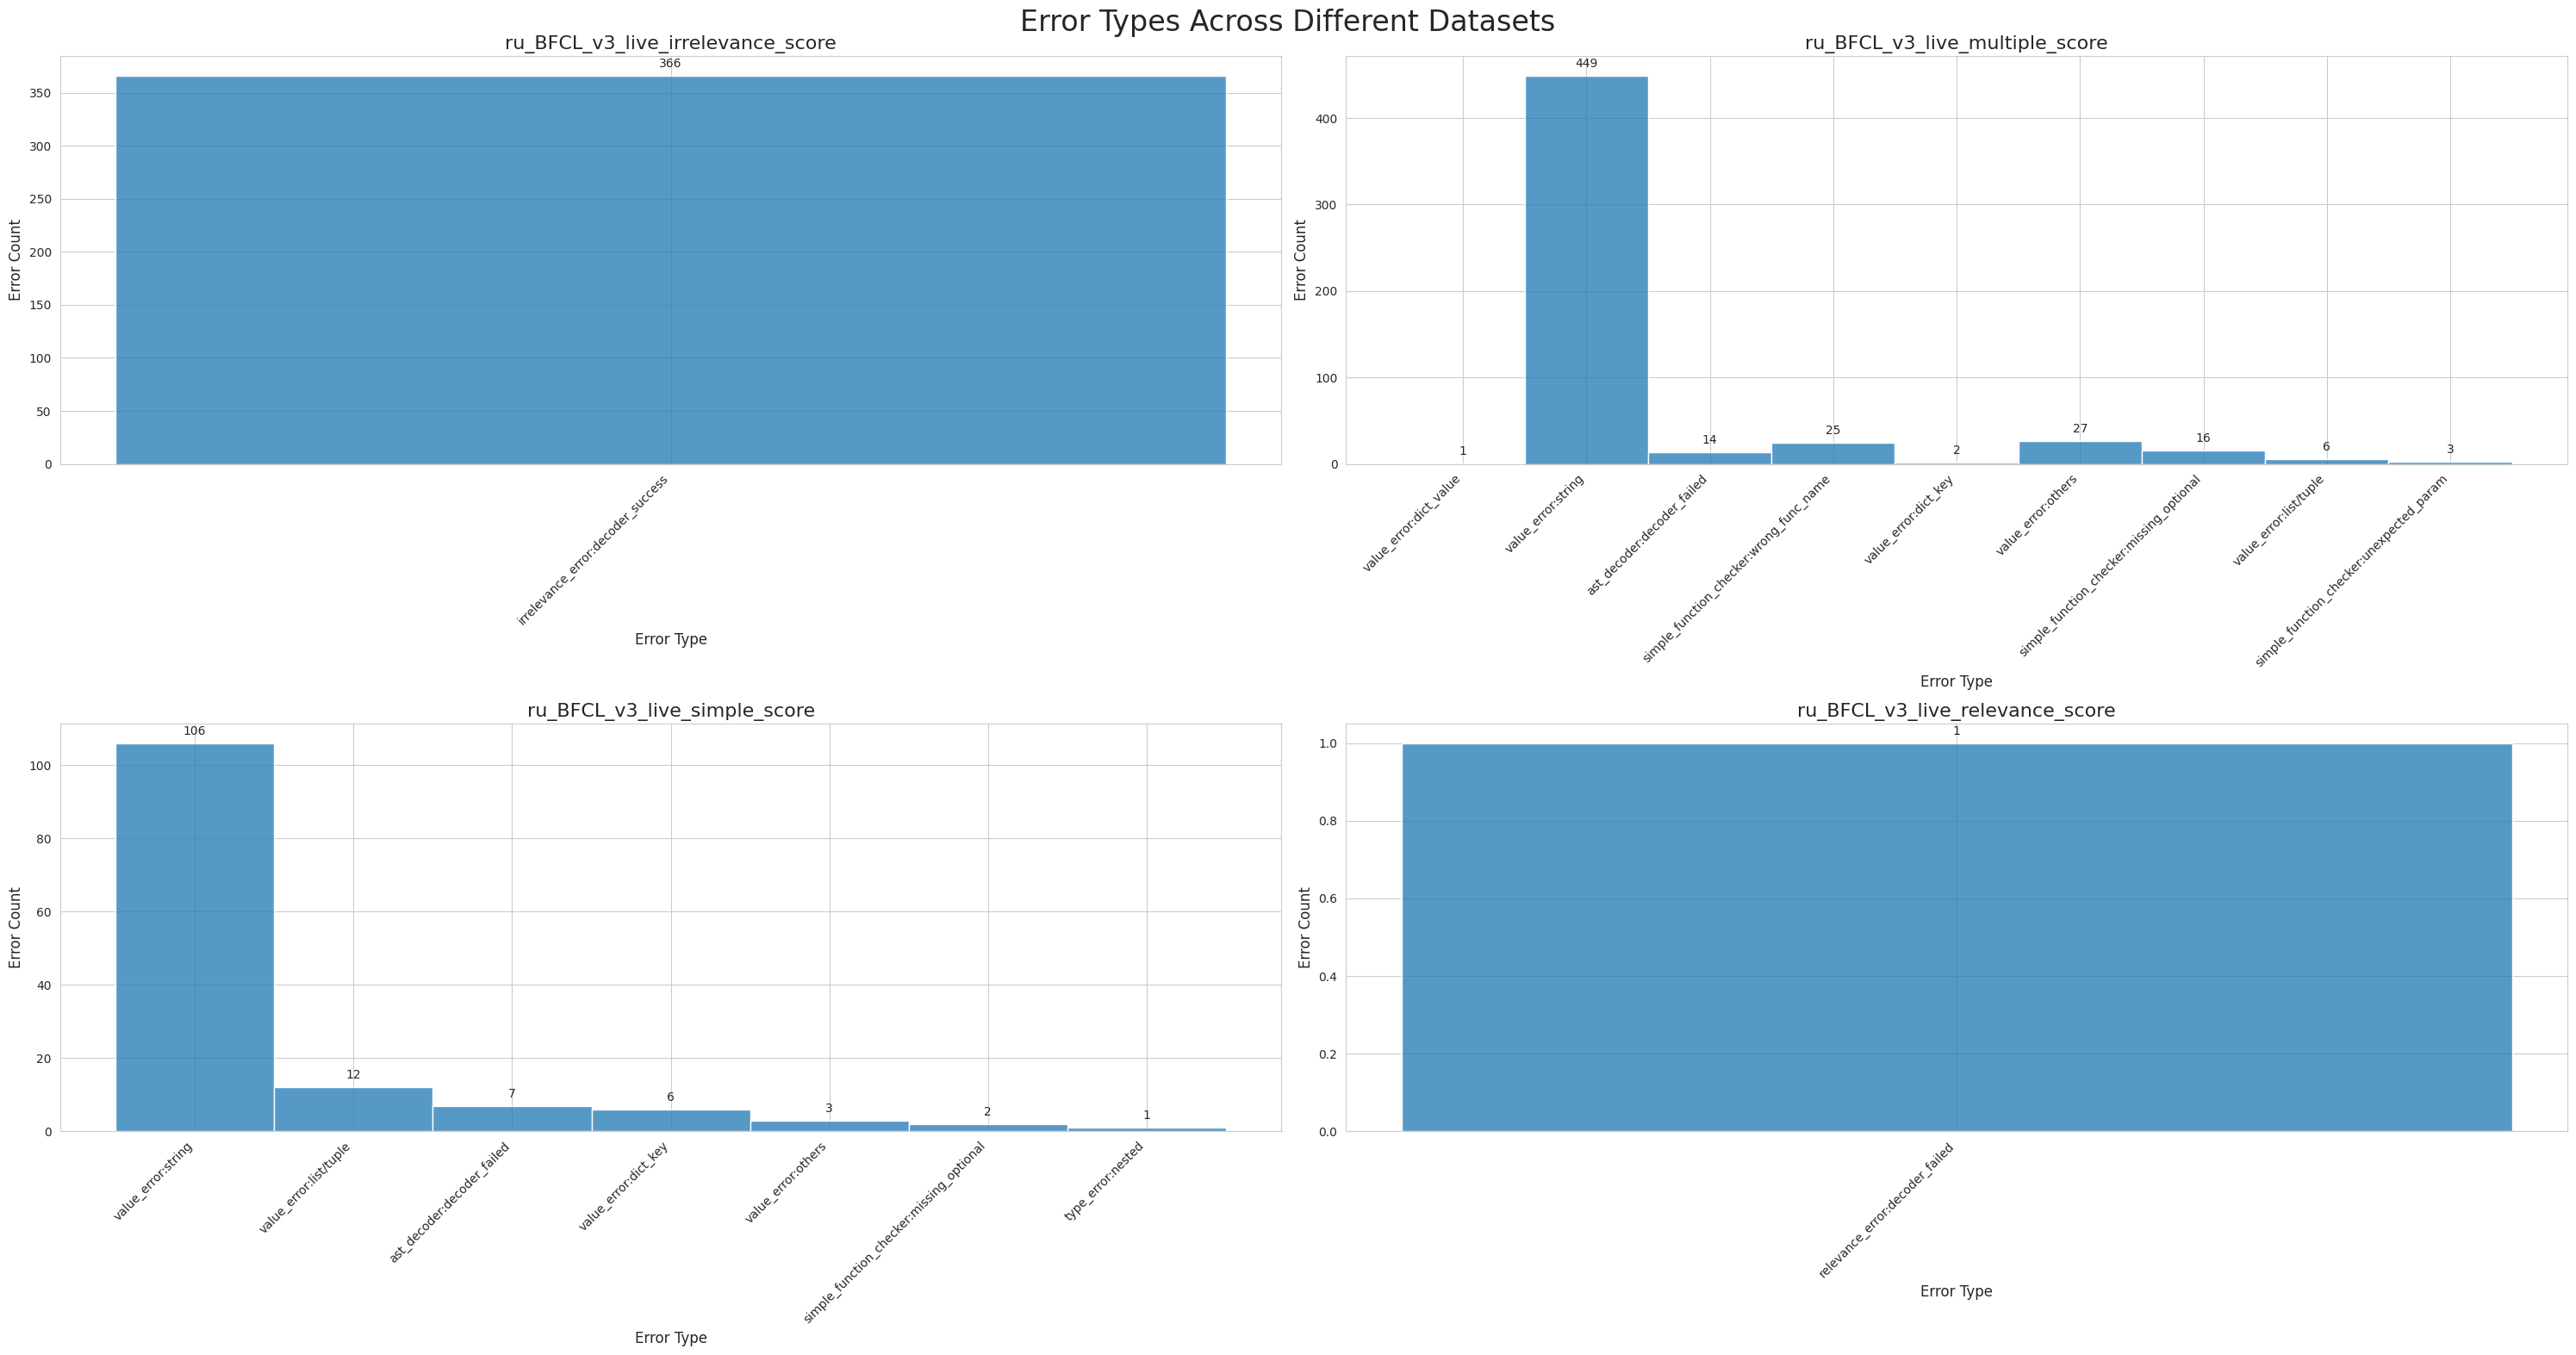

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path


def plot_error_types_from_directory(directory_path):
    # Get all JSON files in the directory
    json_files = list(Path(directory_path).glob("*live*.json"))

    # Set up the plot style
    sns.set_style("whitegrid")

    # Calculate the number of rows and columns for subplots
    n_files = len(json_files)
    n_cols = 2  # You can adjust this if you want more or fewer columns
    n_rows = (n_files + 1) // n_cols

    # Create a figure with subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15 * n_cols, 8 * n_rows))
    fig.suptitle("Error Types Across Different Datasets", fontsize=24)

    # Flatten the axes array for easier indexing
    axes = axes.flatten()

    for i, json_file in enumerate(json_files):
        # Read JSON file
        df = pd.read_json(json_file, lines=True)

        # Extract file name for the title
        file_name = json_file.stem

        # Plot histogram on the corresponding subplot
        ax = axes[i]
        sns.histplot(
            data=df, x="error_type", stat="count", kde=False, ax=ax, palette="deep"
        )

        # Customize the subplot
        ax.set_title(file_name, fontsize=16)
        ax.set_xlabel("Error Type", fontsize=12)
        ax.set_ylabel("Error Count", fontsize=12)

        # Rotate x-axis labels
        ax.tick_params(axis="x", rotation=45)
        ax.set_xticklabels(ax.get_xticklabels(), ha="right")

        # Add count labels on top of each bar
        for p in ax.patches:
            ax.annotate(
                f"{int(p.get_height())}",
                (p.get_x() + p.get_width() / 2.0, p.get_height()),
                ha="center",
                va="center",
                xytext=(0, 10),
                textcoords="offset points",
            )

    # Remove any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # Adjust layout to prevent overlapping
    plt.tight_layout()

    # Show the plot
    plt.show()


# Usage
runs_dir = "/home/jovyan/gigachat/function_calling/gorilla/berkeley-function-call-leaderboard/GC_2_0_2904_ru_bfcl/gc_max_SCORES/gigachat"
plot_error_types_from_directory(runs_dir)

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import openpyxl
from openpyxl.drawing.image import Image
from openpyxl.utils.dataframe import dataframe_to_rows
from io import BytesIO


def plot_error_types_from_directory(directory_path, output_excel_path):
    # Get all JSON files in the directory
    json_files = list(Path(directory_path).glob("*.json"))

    # json_files = [f for f in json_files if "relevance" not in f.stem]

    # Create a new Excel workbook
    workbook = openpyxl.Workbook()

    for json_file in json_files:
        if "live" in json_file.stem or "multi_turn" in json_file.stem:
            # Read JSON file
            df = pd.read_json(json_file, lines=True)
            # Common columns for all sheets
            columns = ["id", "test_category", "error", "error_type", "prompt"]

            # Extract file name for the sheet name
            sheet_name = json_file.stem

            # Create a new sheet
            sheet = workbook.create_sheet(title=sheet_name)
            is_multiturn = False

            if "relevance" in sheet_name:
                columns += ["model_result", "decoded_result"]
                x_ticks_rotation = 0
            elif "multi_turn" in sheet_name:
                is_multiturn = True
                del columns[3]
                # columns += ['model_result_raw', 'model_result_decoded', 'possible_answer', 'inference_log', 'model_result']
                columns += [
                    "model_result_raw",
                    "model_result_decoded",
                    "possible_answer",
                    "inference_log",
                ]
            else:
                columns += [
                    "model_result_raw",
                    "model_result_decoded",
                    "possible_answer",
                ]
                x_ticks_rotation = 45

            # Convert any list or dict to string
            for col in columns:
                try:
                    df[col] = df[col].apply(
                        lambda x: str(x) if isinstance(x, (list, dict)) else x
                    )
                except Exception as e:
                    print(e)
                    continue

            # Write DataFrame to sheet
            for r in dataframe_to_rows(df.loc[1:, columns], index=False, header=True):
                sheet.append(r)

            if not is_multiturn:
                # Create plot
                plt.figure(figsize=(10, 6))
                sns.set_style("whitegrid")
                ax = sns.histplot(
                    data=df, y="error_type", stat="count", kde=False, palette="deep"
                )
                ax.set_title(f"Error Types for {sheet_name}", fontsize=16)
                ax.set_xlabel("Error Count", fontsize=12)
                ax.set_ylabel("", fontsize=12)
                ax.tick_params(axis="y", rotation=0)
                # ax.set_xticklabels(ax.get_xticklabels(), ha='right')

                # Add count labels on top of each bar

                # Annotate each bar with its count value
                for p in ax.patches:
                    width = p.get_width()
                    ax.text(
                        width + 0.1,  # x-coordinate (count value + small offset)
                        p.get_y()
                        + p.get_height() / 2,  # y-coordinate (middle of the bar)
                        f"{int(width)}",  # Text to display (count value)
                        va="center",
                    )  # Vertical alignment

                # for p in ax.patches:
                #     ax.annotate(f'{int(p.get_height())}',
                #                 (p.get_x() + p.get_width() / 2., p.get_height()),
                #                 ha='center', va='center',
                #                 xytext=(0, 10),
                #                 textcoords='offset points')

                # Save plot to BytesIO object
                img_buffer = BytesIO()
                plt.savefig(img_buffer, format="png", bbox_inches="tight")
                img_buffer.seek(0)

                # Add plot to sheet
                img = Image(img_buffer)
                sheet.add_image(img, "J2")  # Adjust the cell reference as needed

                plt.close()  # Close the plot to free up memory

    # Remove the default sheet created by openpyxl
    workbook.remove(workbook["Sheet"])

    # Save the Excel file
    workbook.save(output_excel_path)


# Usage
directory_path = "/home/jovyan/gigachat/function_calling/gorilla/berkeley-function-call-leaderboard/GC_2_0_3000_ru/gc_max_SCORES/gigachat"
output_excel_path = "ru_BFCL_errors.xlsx"
plot_error_types_from_directory(directory_path, output_excel_path)

/tmp/ipykernel_2767061/2370867229.py:61: UserWarning:

Ignoring `palette` because no `hue` variable has been assigned.

/tmp/ipykernel_2767061/2370867229.py:61: UserWarning:

Ignoring `palette` because no `hue` variable has been assigned.

/tmp/ipykernel_2767061/2370867229.py:61: UserWarning:

Ignoring `palette` because no `hue` variable has been assigned.

/tmp/ipykernel_2767061/2370867229.py:61: UserWarning:

Ignoring `palette` because no `hue` variable has been assigned.

/home/jovyan/.mlspace/envs/BFCL_new/lib/python3.10/site-packages/openpyxl/workbook/child.py:99: UserWarning:

Title is more than 31 characters. Some applications may not be able to read the file

/home/jovyan/.mlspace/envs/BFCL_new/lib/python3.10/site-packages/openpyxl/workbook/child.py:99: UserWarning:

Title is more than 31 characters. Some applications may not be able to read the file

/home/jovyan/.mlspace/envs/BFCL_new/lib/python3.10/site-packages/openpyxl/workbook/child.py:99: UserWarning:

Title is more than

In [ ]:
import pandas as pd
import os
from plotly import graph_objects as go
from plotly.offline import plot
import json


def two_excel_to_html_with_plot(
    file1_path,
    file2_path,
    output_html="benchmark_comparison.html",
    title1="Model A",
    title2="Model B",
):
    """
    Reads two Excel files and generates an HTML report with:
    - Two formatted tables
    - A Plotly-powered interactive accuracy comparison bar chart
    """

    def load_and_process_excel(file_path, model_name):
        if not os.path.exists(file_path):
            raise FileNotFoundError(f"File not found: {file_path}")

        df = pd.read_excel(file_path, sheet_name=0, header=0)
        df = df.dropna(axis=1, how="all").dropna(how="all")
        df.columns = df.columns.str.strip()

        for col in df.columns:
            if df[col].dtype == "object":
                df[col] = df[col].astype(str).str.strip()

        if "High-Level Category" not in df.columns:
            raise ValueError(f"'High-Level Category' missing in {file_path}")

        df["High-Level Category"] = df["High-Level Category"].replace("nan", pd.NA)
        df["High-Level Category"] = df["High-Level Category"].fillna(method="ffill")

        df["Correct Count"] = pd.to_numeric(df["Correct Count"], errors="coerce")
        df["Total Count"] = pd.to_numeric(df["Total Count"], errors="coerce")
        df["Accuracy, %"] = pd.to_numeric(df["Accuracy, %"], errors="coerce")

        df["Model"] = model_name
        category_rowspan = df["High-Level Category"].value_counts().to_dict()

        return df, category_rowspan

    # Load both files
    try:
        df1, rowspan1 = load_and_process_excel(file1_path, title1)
        df2, rowspan2 = load_and_process_excel(file2_path, title2)
    except Exception as e:
        print(f"Error: {e}")
        return

    # Extract accuracy data
    acc1 = df1[["Subcategory", "Accuracy, %"]].dropna().set_index("Subcategory")
    acc2 = df2[["Subcategory", "Accuracy, %"]].dropna().set_index("Subcategory")

    # Merge on Subcategory
    merged = acc1.join(
        acc2, lsuffix=f" ({title1})", rsuffix=f" ({title2})", how="inner"
    )

    if merged.empty:
        comparison_plot = (
            "<p><em>No overlapping subcategories found for comparison.</em></p>"
        )
    else:
        merged = merged.reset_index()
        model1_col = [col for col in merged.columns if title1 in col][0]
        model2_col = [col for col in merged.columns if title2 in col][0]

        # Create Plotly bar chart
        fig = go.Figure()

        fig.add_trace(
            go.Bar(
                name=title1,
                x=merged["Subcategory"],
                y=merged[model1_col],
                text=[f"{val:.1f}%" for val in merged[model1_col]],
                textposition="outside",
                textangle=0,
                marker_color="rgb(52, 152, 219)",  # Blue
                hovertemplate=f"{title1}<br>Accuracy: %{{y:.1f}}%<extra></extra>",
            )
        )

        fig.add_trace(
            go.Bar(
                name=title2,
                x=merged["Subcategory"],
                y=merged[model2_col],
                text=[f"{val:.1f}%" for val in merged[model2_col]],
                textposition="outside",
                textangle=0,
                marker_color="rgb(231, 76, 60)",  # Red
                hovertemplate=f"{title2}<br>Accuracy: %{{y:.1f}}%<extra></extra>",
            )
        )

        # Update layout
        fig.update_layout(
            title={
                "text": f"Accuracy Comparison: {title1} vs {title2}",
                "x": 0.5,
                "xanchor": "center",
                "font": {"size": 18},
            },
            xaxis_title="Subcategory",
            yaxis_title="Accuracy (%)",
            yaxis=dict(
                range=[0, 100],
                tickvals=list(range(0, 101, 10)),
                gridcolor="lightgray",
                gridwidth=1,
            ),
            barmode="group",
            bargap=0.15,
            bargroupgap=0.1,
            hovermode="closest",
            showlegend=True,
            legend=dict(x=0.02, y=0.98, bgcolor="rgba(255,255,255,0.8)"),
            margin=dict(l=40, r=40, t=80, b=120),  # Extra bottom margin for labels
            height=600,
            width=None,  # Responsive width
            font=dict(size=12),
        )

        # Improve x-axis label readability
        fig.update_xaxes(tickangle=-55, tickfont=dict(size=12), title_standoff=10)

        # Convert Plotly figure to HTML div string
        plot_div = plot(fig, output_type="div", include_plotlyjs="cdn")
        comparison_plot = (
            f'<div style="text-align: center; margin: 40px 0;">{plot_div}</div>'
        )

    # === Generate HTML ===
    html = """<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <title>GigaChat-2-Max:2.0.29.04</title>
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <style>
        body {
            font-family: Arial, sans-serif;
            margin: 20px;
            background-color: #f7f9fc;
            color: #333;
        }
        h1 {
            text-align: center;
            color: #2c3e50;
            margin-bottom: 10px;
        }
        h2 {
            color: #2980b9;
            border-bottom: 2px solid #3498db;
            padding-bottom: 5px;
            margin-top: 40px;
        }
        p {
            text-align: center;
            color: #7f8c8d;
            font-style: italic;
        }
        table {
            width: 100%;
            border-collapse: collapse;
            box-shadow: 0 0 15px rgba(0,0,0,0.1);
            background-color: white;
            margin: 20px 0;
        }
        th, td {
            padding: 12px 15px;
            text-align: center;
            border-bottom: 1px solid #ddd;
        }
        th {
            background-color: #34495e;
            color: white;
            font-weight: bold;
        }
        .category {
            background-color: #3498db;
            color: white;
            font-weight: bold;
            vertical-align: middle;
        }
        .accuracy-good {
            background-color: #d4edda;
            color: #155724;
            font-weight: bold;
        }
        .accuracy-medium {
            background-color: #fff3cd;
            color: #856404;
            font-weight: bold;
        }
        .accuracy-poor {
            background-color: #f8d7da;
            color: #721c24;
            font-weight: bold;
        }
    </style>
</head>
<body>
    <h1>GigaChat-2-Max:2.0.29.04 Results</h1>
    <p>Accuracy comparison between original and russian versions of BFCL</p>
"""

    def generate_table(df, category_rowspan, title):
        html = f"<h2>{title}</h2>\n<table>\n  <thead>\n    <tr>\n"
        for col in df.columns:
            if col != "Model":
                html += f"      <th>{col}</th>\n"
        html += "    </tr>\n  </thead>\n  <tbody>\n"

        current_category = ""
        for _, row in df.iterrows():
            category = row["High-Level Category"]
            subcategory = row["Subcategory"]
            correct = (
                int(row["Correct Count"]) if pd.notna(row["Correct Count"]) else ""
            )
            total = int(row["Total Count"]) if pd.notna(row["Total Count"]) else ""

            acc_val = row["Accuracy, %"]
            if pd.notna(acc_val):
                if acc_val >= 70:
                    acc_class = "accuracy-good"
                elif acc_val >= 50:
                    acc_class = "accuracy-medium"
                else:
                    acc_class = "accuracy-poor"
                acc_text = f"{acc_val:.2f}%"
            else:
                acc_class = ""
                acc_text = ""

            html += "    <tr>\n"
            if category != current_category:
                html += f'      <td class="category" rowspan="{category_rowspan[category]}">{category}</td>\n'
                current_category = category

            html += f"      <td>{subcategory}</td>\n"
            html += f"      <td>{correct}</td>\n"
            html += f"      <td>{total}</td>\n"
            html += f'      <td class="{acc_class}">{acc_text}</td>\n'
            html += "    </tr>\n"

        html += "  </tbody>\n</table>\n"
        return html

    html += generate_table(df1, rowspan1, title1)
    html += generate_table(df2, rowspan2, title2)
    html += comparison_plot
    html += "</body></html>"

    with open(output_html, "w", encoding="utf-8") as f:
        f.write(html)

    print(f"✅ HTML report with Plotly comparison plot generated: {output_html}")

In [16]:
data_dir = "/home/jovyan/gigachat/function_calling/gorilla/berkeley-function-call-leaderboard/data"
datasets = [
    "BFCL_v3_simple.json",
    "BFCL_v3_multiple.json",
    "BFCL_v3_java.json",
    "BFCL_v3_javascript.json",
    "BFCL_v3_live_simple.json",
    "BFCL_v3_live_multiple.json",
    "BFCL_v3_irrelevance.json",
    "BFCL_v3_live_irrelevance.json",
    "BFCL_v3_live_relevance.json",
]